# Week 4 — Data Cleaning 

🧹

Data Pre-processing is a big part of classical machine learning. This can take up a lot of our time and mental energy 😫. Espcially when you are working on a specialized field such as materials science, this is where your domain knowledge becomes essential.  


You know how meat 🍗, grains and vegetables 🌽 are the ingredients to a dish, but if the ingredients are bad, the dish will be bad too - no matter how good the recipe is! Well, the same idea applies to machine learning. 
Data are the **ingredients** we feed to a machine-learning model, and if there are any *bad* ingredients, the output of the exercise will be bad no matter how good the model is!

If the data is *not clean*, we can run into:

- problems just **handling** the data (the code breaks or behaves strangely),
- **misleading patterns** (the model learns something that isn't real), and
- **bad generalisation** (the model works on our table but fails on new materials).

Most classical ML models assume the data are **clean, numerical, and well-structured**.

:::{admonition} 🚮  Garbage in → garbage out (GIGO)
:class: tip
If you put *garbage* into a model, you get *garbage* out.
Cleaning the data first is one of the most important steps in any ML project -
and often the one that takes the most time 🕜.
:::

:::{note}
All datasets on this page are **small and constructed for teaching**. The numbers are
illustrative (chosen to make a point clearly), not measurements taken from a specific source.
:::

## What do we mean when we say the data is *not clean*?

We will look at five common problems, one at a time:

1. **Missing data** - some values are simply not there.
2. **Incorrect data** - values that cannot be right (e.g. a negative temperature in Kelvin).
3. **Outliers** - values that sit far away from the rest of the data.
4. **Data type inconsistencies** - numbers stored as text, or mixed types in one column.
5. **Duplicates** - the same row appears more than once.

:::{dropdown} 🔑 Words to listen for
- **Missing value / NaN** - an empty cell. `NaN` means *"Not a Number"*.
- **Impute** - to *fill in* a missing value with a sensible estimate.
- **Outlier** - a point that lies far from the others.
- **Data type (dtype)** - what kind of value a column holds: number (`float`, `int`) or text (`object` / `str`).
- **Duplicate** - an identical, repeated row.
- **Coerce** - to *force* a conversion (e.g. turn text into numbers, marking failures as `NaN`).
:::

# Explore the Data 🔎

Before we start cleaning 🧹, we need to really look 👀 at our data 🔬.

For this we can use a variety of functions such as:
`print(data)`
`data.describe()`
`data.info()`
`data.head()`
`data.tail()`
`len(data)`
`data.shape`

And look 👀 at the output closely -> they can give you clues about issues that are in the dataset and things that will need to be cleaned up. 

# Lecture recording
    
:::{seealso} Please refer to the lecture recording on Canvas :::

# Work out an example

Let's look at each of these problems with examples.
Open a new Jupyter notebook: Write down the code snippets in the cells of your notebook.

If you are feeling lazy, you may copy and paste them, but if you really want to practice and learn the coding parts - then you should type them out word-by-word. 🧠 💪


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.2f}") # See if you can figure out what this does

## ❓ 1. Missing data

Real materials tables almost always have gaps: a measurement wasn't taken, a value was
lost, or a database simply didn't have it. Pandas shows these gaps as `NaN`.

Let's build a tiny (constructed) table of ceramics and put a few gaps in it.

In [3]:
# A small, constructed dataset. temperature_K, density and hardness are illustrative.
materials = pd.DataFrame({
    "formula":       ["Al2O3", "SiC", "MgO", "TiO2", "ZrO2", "Si3N4", "WC", "B4C"],
    "temperature_K": [300, 300, np.nan, 300, 500, 300, np.nan, 300],
    "density_g_cm3": [3.95, 3.21, 3.58, 4.23, 5.68, 3.17, 15.60, 2.52],
    "hardness_GPa":  [15.0, 25.0, 9.0, np.nan, 12.0, 16.0, 22.0, np.nan],
})
materials

,formula,temperature_K,density_g_cm3,hardness_GPa
0,Al2O3,300.00,3.95,15.00
1,SiC,300.00,3.21,25.00
2,MgO,NaN,3.58,9.00
3,TiO2,300.00,4.23,NaN
4,ZrO2,500.00,5.68,12.00
5,Si3N4,300.00,3.17,16.00
6,WC,NaN,15.60,22.00
7,B4C,300.00,2.52,NaN


A quick way to *count* the gaps in each column is `.isna().sum()`:

In [4]:
materials.isna().sum()

formula          0
temperature_K    2
density_g_cm3    0
hardness_GPa     2
dtype: int64

### Three ways to deal with missing data

1. **Drop** the rows (or columns) that contain gaps - simple, but you lose data.
2. **Impute** - fill the gaps with a sensible value (e.g. the column *average*, or a value
   looked up from a trusted source).
3. **Use a model that handles missing data** natively (e.g. **XGBoost**).

:::{tip}
Dropping is easy but wasteful: if every row has *one* gap somewhere, `dropna()` can throw
away your whole table. So, you will have to consider this carefully before dropping. Impute when you can afford to.
:::

You can find the details of [dropna() here.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html)  



In [5]:
# Option 1 — drop any row that has a missing value
print("shape before drop :", materials.shape)
print("shape after  drop :", materials.dropna().shape)

shape before drop : (8, 4)
shape after  drop : (4, 4)


When you use the `dropna()` function, if no arguments are specified, then it will use the default values.
*dropna() = dropna(axis=0,how=any,inplace=False,ignore_index=False)*


:::{tip}
:class: important
❗Note that `materials.dropna()` shows you what the output would be if the data is dropped. But to keep the changes, you need to save the changes.

`materials = materials.dropna()`

An alternative is to set the argument `inplace=True`.

:::

In [6]:
# Option 2 — impute: fill numeric gaps with that column's mean
num_cols = ["temperature_K", "density_g_cm3", "hardness_GPa"]

materials_imputed = materials.copy() #Making a copy just in case we mess it up 
materials_imputed[num_cols] = materials_imputed[num_cols].fillna(
    materials_imputed[num_cols].mean().round(2)
)
materials_imputed

,formula,temperature_K,density_g_cm3,hardness_GPa
0,Al2O3,300.00,3.95,15.00
1,SiC,300.00,3.21,25.00
2,MgO,333.33,3.58,9.00
3,TiO2,300.00,4.23,16.50
4,ZrO2,500.00,5.68,12.00
5,Si3N4,300.00,3.17,16.00
6,WC,333.33,15.60,22.00
7,B4C,300.00,2.52,16.50


In a real ML pipeline you would usually use scikit-learn's `SimpleImputer`, because it
fits neatly into a training pipeline and remembers the fill values for later. But you don't have to worry about it now.

:::{seealso} Two things to remember for ML
:class: important
- **Avoid data leakage.** Compute the fill value (e.g. the mean) from the **training data only**,
  then apply the *same* value to the test data. `SimpleImputer` does this for you when used inside a pipeline.
If you don't know what this means, don't worry - we will get back to the idea of **data leakage** later on.
- Some models, such as **XGBoost**, can accept `NaN` directly and learn how to handle it - no imputation needed.
:::

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")   # in practice: fit on train, transform on test
filled = imputer.fit_transform(materials[num_cols])

print("First 3 rows after SimpleImputer (temperature_K, density, hardness):")
print(np.round(filled[:3], 2))

## 2. Incorrect data

Some values are not *missing* -they are simply **wrong**. The best tool for spotting these
is your own **domain knowledge** - your expertise. A temperature in Kelvin, for example, can never be negative, a bandgap value may never be in their thousands, Physics laws need to hold up in the measurements/computations etc.

Here is a constructed heat-capacity table for one compound. Two rows look wrong.

In [8]:
# Constructed Cp-vs-temperature data for one compound.
df_inc = pd.DataFrame({
    "formula": ["Mg2O4Ti1"] * 8,
    "T_K": [1600, 1700, 1800, 288.5001548, -2000, 2100, 2200, 2300],
    "Cp":  [206.0, 209.4, 212.6, 111.1, 218.8, 221.8, 224.8, 227.6],
})
df_inc.style.format({"T_K": "{:.7f}", "Cp": "{:.1f}"})

,formula,T_K,Cp
0,Mg2O4Ti1,1600.0000000,206.0
1,Mg2O4Ti1,1700.0000000,209.4
2,Mg2O4Ti1,1800.0000000,212.6
3,Mg2O4Ti1,288.5001548,111.1
4,Mg2O4Ti1,-2000.0000000,218.8
5,Mg2O4Ti1,2100.0000000,221.8
6,Mg2O4Ti1,2200.0000000,224.8
7,Mg2O4Ti1,2300.0000000,227.6


Two problems are hiding here:

- **`T_K = -2000`** - impossible, because temperature in Kelvin cannot be negative.
- **`T_K = 288.5001548`** - *suspiciously* over-precise and out of order compared to its
  neighbours. It may have come from a bad merge or a copy-paste error.

We can catch the clearly impossible ones with a simple rule from physics:

In [ ]:
# Domain rule: temperature in Kelvin must be positive
impossible = df_inc[df_inc["T_K"] <= 0]
impossible

,formula,T_K,Cp
4,Mg2O4Ti1,-2000.00,218.80


### How to clean incorrect data

- **Check against a trusted database.** In materials science, tools like
  **pymatgen** / the Materials Project can help you verify a value.
- **Exclude** the point if the situation allows it (and you are confident it is an error).
- **Compare two models**, one *with* and one *without* the suspicious points, and see whether
  it changes your conclusions.

:::{warning}
Don't delete a value just because it looks odd. First decide *why* it is wrong.
"Impossible" (negative Kelvin) is very different from merely "surprising".
:::

## 3. Outliers

An **outlier** is a point that sits far away from the rest of the data. Look at the point at
the top of this (constructed) plot - it clearly doesn't belong with the others.

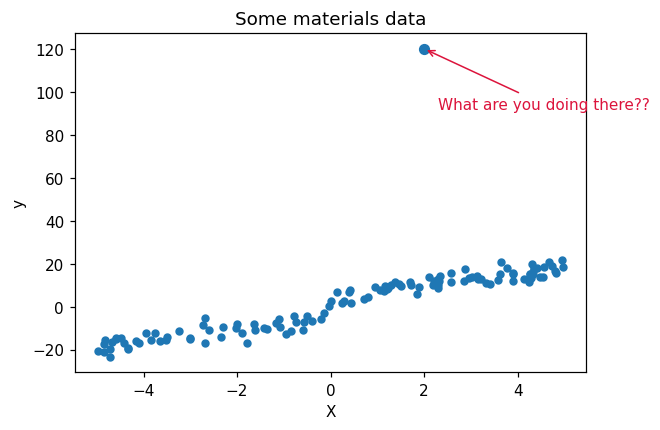

In [ ]:
rng = np.random.default_rng(0)
x = rng.uniform(-5, 5, 120)
y = 8 * np.sign(x) * np.sqrt(np.abs(x)) + rng.normal(0, 2.5, 120)

# plant one obvious outlier
x_out, y_out = 2.0, 120.0

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=20)
ax.scatter([x_out], [y_out], s=40, color="tab:blue")
ax.annotate("What are you doing there??", xy=(x_out, y_out), xytext=(2.3, 92),
            color="crimson", arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_title("Some materials data")
ax.set_xlabel("X"); ax.set_ylabel("y")
plt.show()

### Why outliers matter

Many statistics are **sensitive** to outliers. The **mean** is pulled towards extreme values,
and if you use a metric like Mean Squared Error (**MSE**) which *squares* the errors, a single far-away point can dominate the whole loss.

The **median**, on the other hand, barely moves. Watch what one bad value does:

In [ ]:
# Grain sizes in microns; the 250 is a data-entry error (a real one would be ~12)
grain_sizes = np.array([12, 13, 11, 14, 12, 13, 250, 12, 11, 13])
clean = grain_sizes[grain_sizes != 250]

print(f"mean   WITH outlier : {grain_sizes.mean():.1f}")
print(f"mean   WITHOUT      : {clean.mean():.1f}   <- the mean was dragged way up")
print(f"median WITH outlier : {np.median(grain_sizes):.1f}")
print(f"median WITHOUT      : {np.median(clean):.1f}   <- the median hardly moved")

mean   WITH outlier : 36.1
mean   WITHOUT      : 12.3   <- the mean was dragged way up
median WITH outlier : 12.5
median WITHOUT      : 12.0   <- the median hardly moved


### A simple way to flag outliers: the IQR rule

One common, easy rule uses the **interquartile range (IQR)** = Q3 - Q1 (the spread of the
middle 50% of the data). Anything below `Q1 - 1.5·IQR` or above `Q3 + 1.5·IQR` is *flagged*
as a possible outlier - ⚠️ flagged for a closer look, not automatically deleted.

In [ ]:
q1, q3 = np.percentile(grain_sizes, [25, 75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

flagged = grain_sizes[(grain_sizes < low) | (grain_sizes > high)]
print(f"IQR bounds : [{low:.1f}, {high:.1f}]")
print(f"flagged    : {flagged}")

IQR bounds : [10.5, 14.5]
flagged    : [250]


## 🤔 The suspicious twist: is an outlier always bad?

**Not in materials discovery!** Sometimes the outlier is the whole point - the unusual
material with a remarkable property is exactly what we are hunting for 🔍.

Below, *Tetragonal Zirconia* has a much higher fracture toughness than the other ceramics
(values are illustrative). In a routine analysis you might call it an outlier and drop it -
but here it may be a genuine, exciting result.

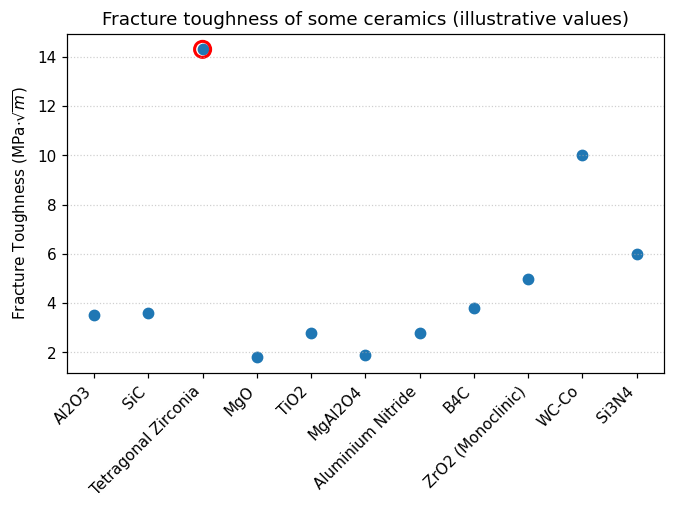

In [ ]:
mats = ["Al2O3", "SiC", "Tetragonal Zirconia", "MgO", "TiO2", "MgAl2O4",
        "Aluminium Nitride", "B4C", "ZrO2 (Monoclinic)", "WC-Co", "Si3N4"]
K = [3.5, 3.6, 14.3, 1.8, 2.8, 1.9, 2.8, 3.8, 5.0, 10.0, 6.0]  # illustrative

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(range(len(mats)), K, s=45, color="tab:blue")
zi = mats.index("Tetragonal Zirconia")
ax.scatter([zi], [K[zi]], s=110, facecolors="none", edgecolors="red", linewidths=2)
ax.set_xticks(range(len(mats)))
ax.set_xticklabels(mats, rotation=45, ha="right")
ax.set_ylabel(r"Fracture Toughness (MPa⋅m)")
ax.set_title("Fracture toughness of some ceramics (illustrative values)")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

:::{important} The key habit
Before removing an outlier, ask **why** it is there:

- **Is it an error?** (a typo, a broken sensor, a bad merge) → it is safe to drop it.
- **Is it real?** (a genuinely unusual material) → keep it, and **verify against another source**
  (e.g. a database) to confirm it is valid.

When in doubt, don't delete - investigate 🔍.
:::

## 4. Data type inconsistencies 🔀

Sometimes the values are correct, but stored in the **wrong type**. The most common cases:

- **Numbers stored as text** (strings). For example, if you used Python's `input()` to ask the user for a number, it always returns a string, so `"55"` is text, not the number `55`.
- **Mixed types in one column** (some numbers, some words).
- **Missing values written as text** like `'-'`, `'N/A'`, or `'null'`. These *look* like missing values to us,
  but Python does **not** recognise them as `NaN` automatically.

Here a hardness column has been read in as text, with a few junk markers mixed in.

In [9]:
raw = pd.DataFrame({
    "sample":   [1, 2, 3, 4, 5, 6, 7, 8],
    "hardness": ["27", "-", "30", "31", "N/A", "28", "null", "29"],
})

print("dtypes BEFORE cleaning:")
print(raw.dtypes)          # 'hardness' is text (object / str), not numeric
raw

dtypes BEFORE cleaning:
sample      int64
hardness      str
dtype: object


,sample,hardness
0,1,27
1,2,-
2,3,30
3,4,31
4,5,N/A
5,6,28
6,7,null
7,8,29


Because of the few text markers, pandas keeps the whole column as **text** - see that it outputs hardness as a `str`?. We can fix it in two steps:

1. **Replace** the fake-missing markers with a real `NaN`.
2. **Coerce** the column to numbers with `pd.to_numeric(..., errors="coerce")` - anything that
   still can't be converted becomes `NaN`.

In [ ]:
cleaned = raw.copy()

# step 1: turn text markers into real missing values
cleaned["hardness"] = cleaned["hardness"].replace(["-", "N/A", "null", "none", ""], np.nan)

# step 2: force the column to numeric (unconvertible entries -> NaN)
cleaned["hardness"] = pd.to_numeric(cleaned["hardness"], errors="coerce")

print("dtypes AFTER cleaning:")
print(cleaned.dtypes)      # now 'hardness' is float64
cleaned

dtypes AFTER cleaning:
sample        int64
hardness    float64
dtype: object


,sample,hardness
0,1,27.00
1,2,NaN
2,3,30.00
3,4,31.00
4,5,NaN
5,6,28.00
6,7,NaN
7,8,29.00


Now the column is numeric, and the fake-missing markers have become proper `NaN` values -
which we can then handle using the missing-data tools from Section 1.

## 5. Duplicates 

📕📘📙📗📕📕📘 

A **duplicate** is a row that appears more than once. Duplicates can quietly bias a model by
giving some samples extra weight. Pandas finds and removes them with `duplicated()` and
`drop_duplicates()`.

We will talk about **bias** in more detail in the coming weeks. 

In [ ]:
dup = pd.DataFrame({
    "formula":  ["Al2O3", "SiC", "Al2O3", "MgO", "SiC"],
    "T_K":      [300, 300, 300, 300, 300],
    "hardness": [15.0, 25.0, 15.0, 9.0, 25.0],
})

print("Is each row a duplicate of an earlier one?")
print(list(dup.duplicated()))
print(f"\nRows before: {dup.shape[0]}  ->  after drop_duplicates: {dup.drop_duplicates().shape[0]}")
dup.drop_duplicates()

Is each row a duplicate of an earlier one?
[False, False, True, False, True]

Rows before: 5  ->  after drop_duplicates: 3


,formula,T_K,hardness
0,Al2O3,300,15.00
1,SiC,300,25.00
3,MgO,300,9.00


Another useful function is `numpy`'s `unique()`. This gives you the number of unique entries or elements in the data. Although this doesn't find the index of duplicate entries, you can couple it with other numpy functions depending on your requirement. But your data has to be in an array format for these operations.


:::{warning} 	⚠️
Think before you drop! Two identical rows are *not* always a mistake - they might be two
**genuine repeated measurements**. This is where you can refer to *Unique identifiers* such as sample numbers (or student numbers - as two students can have the same name). Only remove duplicates when they truly are copies.
:::

# A Word on Data Leakage 💧

We talked about how we need to be mindful when we do the train-test split for machine learning. You have to make sure that you don't have the same data entries in both the training and the testing sets - or otherwise the model might just 'memorize' those values.

have a look at the below dataset:

In [3]:
import pandas as pd

pd.read_csv("data/lec04-data_leakage.csv")


,formula,T_K,Cp
0,Al2O3,350,90.0
1,Al2O3,900,118.5
2,Ca1O3Ti1,400,98.0
3,Ca1O3Ti1,1000,127.0
4,Fe2O3,320,105.0
5,Fe2O3,850,145.0
6,Mg1O1,380,38.5
7,Mg1O1,1100,52.0
8,O2Si1,310,45.0
9,O2Si1,950,68.0


Now we can't split this into train & test arbitrarily. **Why?** - Because imagine you have the same formmulas appearing across both the train and the test sets - the model can *Cheat*.

So we need to make sure that the same chemical formula appears only in one of the groups. So, both $Al_2O_3$ samples has to be in either the train set or the test set, but not in both. Same with the others.

And how do we manage this?
Well, good news is that Python has a function for everything, instead of using `train_test_split()` we can use `GroupShuffleSplit()`.

## And how does data pre-processing such as Imputing affect data leakage

During pre-processing if we impute a missing value using the whole data column - we are averaging over datapoints that are going to be in both the train and the test sets. 
So *indirecly* we are incorporating some information from the training data and the testing data into these imputed values. 

Therefore, if we then do the train-test split - there will be data leakage, and the model can give you better outputs through cheating. And that's why we need to be very careful not to let that happen. 


## Putting it all together 📋

A simple cleaning checklist for a new dataset:

1. **Look** at the data (`.head()`, `.info()`, `.describe()`).
2. **Missing values** - count them (`.isna().sum()`), then drop, impute, or use a model that supports `NaN`.
3. **Incorrect values** - use domain knowledge to catch the impossible; verify the suspicious.
4. **Outliers** - flag them (e.g. IQR), then decide: **error → drop**, **real → investigate**.
5. **Data types** - make sure numeric columns are numeric; convert fake-missing markers to `NaN`.
6. **Duplicates** - remove true copies, but keep genuine repeats.

:::{important} Two golden rules
- **Fit cleaning choices on the training data only** (means, imputers, etc.), then apply them to test data - this avoids *data leakage*.
- **Write down what you changed.** Cleaning is part of your science; it should be reproducible.
:::

Clean data won't guarantee a great model - but **dirty data will almost always guarantee a poor one**.

## Self-test

Try these five questions. Think about your answer first, then click to check.

In [6]:
# Requires jupyterquiz (already in the course environment: pip install jupyterquiz)
from jupyterquiz import display_quiz

my_colors = {
    '--jq-multiple-choice-bg': '#2c7db0',   # question box background
}

display_quiz("quiz/lecture04_cleaning.json",colors=my_colors)

<IPython.core.display.Javascript object>